In [ ]:
!pip install -q nltk textblob vaderSentiment scikit-learn matplotlib seaborn pandas
print(' All libraries installed')

 All libraries installed


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

SEED = 42
np.random.seed(SEED)
print(' All imports successful')

 All imports successful


In [ ]:

TRAIN_URL = 'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv'
TEST_URL  = 'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv'

print('Downloading Banking77 dataset from GitHub...')
train_df = pd.read_csv(TRAIN_URL)
test_df  = pd.read_csv(TEST_URL)

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
print(f'Columns     : {train_df.columns.tolist()}')
print(f'\nSample rows:')
print(train_df.head(5).to_string())

Train shape : (10003, 2)
Test  shape : (3080, 2)
Columns     : ['text', 'category']

Sample rows:
                                                           text      category
0                                I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived after 2 weeks?  card_arrival
2    I have been waiting over a week. Is the card still coming?  card_arrival
3   Can I track my card while it is in the process of delivery?  card_arrival
4        How do I know if I will get my card, or if it is lost?  card_arrival


In [ ]:

label_names = sorted(train_df['category'].unique().tolist())
label2id    = {name: i for i, name in enumerate(label_names)}
id2label    = {i: name for name, i in label2id.items()}
NUM_LABELS  = len(label_names)

train_df['label'] = train_df['category'].map(label2id)
test_df['label']  = test_df['category'].map(label2id)

print(f'Intent classes : {NUM_LABELS}')
print(f'Train samples   : {len(train_df)}')
print(f'Test  samples   : {len(test_df)}')

Intent classes : 77
Train samples   : 10003
Test  samples   : 3080


In [ ]:


vader = SentimentIntensityAnalyzer()

#Negative in banking context
NEGATIVE_INTENTS = {
    'card_not_working', 'card_blocked', 'compromised_card',
    'lost_or_stolen_card', 'declined_card_payment',
    'declined_transfer', 'fraud', 'failed_transfer',
    'cancel_transfer', 'pin_blocked', 'card_payment_not_recognised',
    'direct_debit_payment_not_recognised', 'cash_withdrawal_not_recognised',
    'transfer_not_received_by_recipient', 'balance_not_updated_after_bank_transfer',
    'balance_not_updated_after_cheque_or_cash_deposit',
    'top_up_failed', 'top_up_reverted', 'pending_top_up',
    'pending_transfer', 'pending_card_payment',
    'wrong_amount_of_cash_received', 'wrong_exchange_rate_for_cash_withdrawal'
}

# Positive in banking context
POSITIVE_INTENTS = {
    'card_arrival', 'card_linking', 'order_physical_card',
    'get_physical_card', 'supported_cards_and_currencies',
    'card_delivery_estimate', 'apple_pay_or_google_pay',
    'activate_my_card', 'age_limit'
}

def assign_sentiment(row):
    """
    Assign sentiment to a banking query:
    - First apply domain-aware intent override
    - Fall back to VADER compound score
    Returns: 'Positive', 'Negative', or 'Neutral'
    """
    intent = row['category']
    text   = row['text']

    # Domain override (higher priority)
    if intent in NEGATIVE_INTENTS:
        return 'Negative'
    if intent in POSITIVE_INTENTS:
        return 'Positive'

    # VADER for remaining
    score = vader.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

train_df['sentiment'] = train_df.apply(assign_sentiment, axis=1)
test_df['sentiment']  = test_df.apply(assign_sentiment, axis=1)

print(' Sentiment labels assigned')
print('\nTRAIN sentiment distribution:')
print(train_df['sentiment'].value_counts())
print('\nTEST sentiment distribution:')
print(test_df['sentiment'].value_counts())

 Sentiment labels assigned

TRAIN sentiment distribution:
sentiment
Negative    4149
Neutral     3419
Positive    2435
Name: count, dtype: int64

TEST sentiment distribution:
sentiment
Negative    1161
Neutral     1141
Positive     778
Name: count, dtype: int64


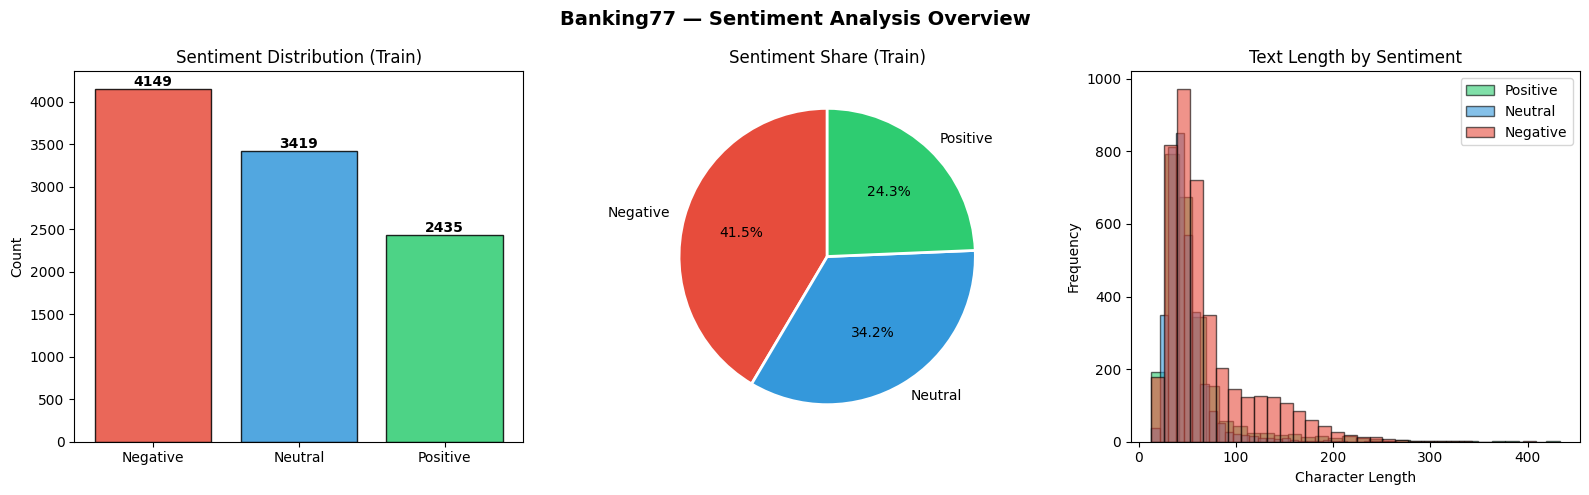

EDA plot saved.


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Banking77 — Sentiment Analysis Overview', fontsize=14, fontweight='bold')

colors = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

# Train
counts = train_df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[colors[s] for s in counts.index], edgecolor='black', alpha=0.85)
axes[0].set_title('Sentiment Distribution (Train)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')


axes[1].pie(
    counts.values, labels=counts.index,
    colors=[colors[s] for s in counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Sentiment Share (Train)')

# Sample text lengths per sentiment
train_df['text_len'] = train_df['text'].apply(len)
for sent, color in colors.items():
    subset = train_df[train_df['sentiment'] == sent]['text_len']
    axes[2].hist(subset, bins=30, alpha=0.6, color=color, label=sent, edgecolor='black')
axes[2].set_title('Text Length by Sentiment')
axes[2].set_xlabel('Character Length')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('sentiment_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

In [ ]:
print('SAMPLE LABELLED EMAILS')
print('=' * 75)
for sent in ['Positive', 'Neutral', 'Negative']:
    print(f'\n--- {sent.upper()} ---')
    samples = train_df[train_df['sentiment'] == sent][['text', 'category']].head(4)
    for _, row in samples.iterrows():
        print(f'  [{row["category"]}]')
        print(f'   "{row["text"]}"')

SAMPLE LABELLED EMAILS

--- POSITIVE ---
  [card_arrival]
   "I am still waiting on my card?"
  [card_arrival]
   "What can I do if my card still hasn't arrived after 2 weeks?"
  [card_arrival]
   "I have been waiting over a week. Is the card still coming?"
  [card_arrival]
   "Can I track my card while it is in the process of delivery?"

--- NEUTRAL ---
  [exchange_rate]
   "Do you know the rate of exchange?"
  [exchange_rate]
   "What foreign exchange rate will I get on weekdays and on the weekends?"
  [exchange_rate]
   "How is the exchange rate doing?"
  [exchange_rate]
   "If I need to cash foreign transfers, how does that work?"

--- NEGATIVE ---
  [card_payment_wrong_exchange_rate]
   "Last Saturday, I was charged extra for the exchange rate on my payment. Is something wrong?"
  [card_payment_wrong_exchange_rate]
   "Hi, I am disappointed to see such a bad exchange rate and hope you can assist me. Would you be able to confirm the official interbank exchange rate for me?"
  [card

In [ ]:
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))
# Keep negation words — important for sentiment!
KEEP_WORDS  = {'no', 'not', "n't", 'never', 'cannot', "can't", 'blocked', 'failed', 'lost'}
stop_words  = stop_words - KEEP_WORDS

def preprocess_text(text: str) -> str:
    """
    Same preprocessing as DistilBERT notebook PLUS:
    - Stop word removal (keeping negations)
    - Lemmatization
    """
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\b\d{8,19}\b', '[account_id]', text)     # Mask PII
    text = re.sub(r'[^a-z\s\[\]]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

# Demo
demos = [
    'My card 4567891234567890 has been blocked and I cannot use it!',
    'I want to check my account balance please.',
    'Someone is using my card without permission!'
]
print('PREPROCESSING DEMO')
print('-' * 60)
for d in demos:
    print(f'  IN : {d}')
    print(f'  OUT: {preprocess_text(d)}')
    print()

# Apply
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)
print(' Preprocessing applied to all samples.')

PREPROCESSING DEMO
------------------------------------------------------------
  IN : My card 4567891234567890 has been blocked and I cannot use it!
  OUT: card [account id] blocked cannot use

  IN : I want to check my account balance please.
  OUT: want check account balance please

  IN : Someone is using my card without permission!
  OUT: someone using card without permission

 Preprocessing applied to all samples.


In [ ]:
# TF-IDF Vectorizer — converts text to numerical feature matrix
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),    # Unigrams + bigrams (e.g. 'card blocked')
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

X_train = tfidf.fit_transform(train_df['clean_text'])
X_test  = tfidf.transform(test_df['clean_text'])

# Encode sentiment labels → 0, 1, 2
le      = LabelEncoder()
y_train = le.fit_transform(train_df['sentiment'])
y_test  = le.transform(test_df['sentiment'])

print(f'TF-IDF feature matrix built')
print(f'   Train features shape : {X_train.shape}')
print(f'   Test  features shape : {X_test.shape}')
print(f'   Vocabulary size      : {len(tfidf.vocabulary_)}')
print(f'   Classes              : {le.classes_}')

# Top 20 TF-IDF terms
feature_names = tfidf.get_feature_names_out()
mean_tfidf    = np.asarray(X_train.mean(axis=0)).flatten()
top20_idx     = mean_tfidf.argsort()[-20:][::-1]
print(f'\n  Top 20 TF-IDF terms: {[feature_names[i] for i in top20_idx]}')

TF-IDF feature matrix built
   Train features shape : (10003, 6541)
   Test  features shape : (3080, 6541)
   Vocabulary size      : 6541
   Classes              : ['Negative' 'Neutral' 'Positive']

  Top 20 TF-IDF terms: ['card', 'top', 'transfer', 'account', 'money', 'get', 'payment', 'not', 'need', 'cash', 'exchange', 'fee', 'charged', 'atm', 'currency', 'app', 'use', 'pin', 'transaction', 'rate']


In [ ]:
# 1. Support Vector Machine (LinearSVC)
print('Training SVM (LinearSVC)...')
svm_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=SEED,
    class_weight='balanced'   # Handles class imbalance
)
svm_model.fit(X_train, y_train)
print('   SVM trained')

# 2. Multinomial Naive Baye
print('Training Naive Bayes (MultinomialNB)...')
nb_model = MultinomialNB(
    alpha=0.1   # Laplace smoothing
)
nb_model.fit(X_train, y_train)
print('   Naive Bayes trained')

#  3. Logistic Regression
print('Training Logistic Regression...')
lr_model = LogisticRegression(
    C=5.0,
    max_iter=1000,
    random_state=SEED,
    class_weight='balanced',
    solver='lbfgs',
    multi_class='multinomial'
)
lr_model.fit(X_train, y_train)
print('   Logistic Regression trained')

print('\n All 3 models trained successfully!')

Training SVM (LinearSVC)...
   SVM trained
Training Naive Bayes (MultinomialNB)...
   Naive Bayes trained
Training Logistic Regression...
   Logistic Regression trained

 All 3 models trained successfully!


In [ ]:
def evaluate_model(model, X_test, y_test, model_name, classes):
    """Evaluate a model and return metrics dict."""
    y_pred = model.predict(X_test)

    acc        = accuracy_score(y_test, y_pred)
    macro_f1   = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    weighted_f1= f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision  = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall     = recall_score(y_test, y_pred, average='macro',    zero_division=0)

    print(f'\n{"-"*55}')
    print(f'  MODEL: {model_name}')
    print(f'{"-"*55}')
    print(f'  Accuracy       : {acc*100:.2f}%')
    print(f'  Macro Precision: {precision:.4f}')
    print(f'  Macro Recall   : {recall:.4f}')
    print(f'  Macro F1       : {macro_f1:.4f}')
    print(f'  Weighted F1    : {weighted_f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

    return {
        'model':        model_name,
        'accuracy':     acc,
        'precision':    precision,
        'recall':       recall,
        'macro_f1':     macro_f1,
        'weighted_f1':  weighted_f1,
        'y_pred':       y_pred
    }

classes = le.classes_

svm_results = evaluate_model(svm_model, X_test, y_test, 'SVM (LinearSVC)',       classes)
nb_results  = evaluate_model(nb_model,  X_test, y_test, 'Naive Bayes (Multinomial)', classes)
lr_results  = evaluate_model(lr_model,  X_test, y_test, 'Logistic Regression',   classes)


-------------------------------------------------------
  MODEL: SVM (LinearSVC)
-------------------------------------------------------
  Accuracy       : 87.69%
  Macro Precision: 0.8739
  Macro Recall   : 0.8762
  Macro F1       : 0.8748
  Weighted F1    : 0.8770

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      1161
     Neutral       0.88      0.90      0.89      1141
    Positive       0.84      0.87      0.86       778

    accuracy                           0.88      3080
   macro avg       0.87      0.88      0.87      3080
weighted avg       0.88      0.88      0.88      3080


-------------------------------------------------------
  MODEL: Naive Bayes (Multinomial)
-------------------------------------------------------
  Accuracy       : 83.99%
  Macro Precision: 0.8386
  Macro Recall   : 0.8341
  Macro F1       : 0.8357
  Weighted F1    : 0.8395

  Classification Report:
              precisi

In [ ]:
# Comparison DataFrame
results_list = [svm_results, nb_results, lr_results]
compare_df = pd.DataFrame([{
    'Model':       r['model'],
    'Accuracy':    round(r['accuracy']*100, 2),
    'Precision':   round(r['precision'], 4),
    'Recall':      round(r['recall'], 4),
    'Macro F1':    round(r['macro_f1'], 4),
    'Weighted F1': round(r['weighted_f1'], 4)
} for r in results_list])

print('\n' + '='*65)
print('         MODEL COMPARISON TABLE')
print('='*65)
print(compare_df.to_string(index=False))
print('='*65)
best = compare_df.loc[compare_df['Macro F1'].idxmax(), 'Model']
print(f'\n Best Model by Macro F1: {best}')


         MODEL COMPARISON TABLE
                    Model  Accuracy  Precision  Recall  Macro F1  Weighted F1
          SVM (LinearSVC)     87.69     0.8739  0.8762    0.8748       0.8770
Naive Bayes (Multinomial)     83.99     0.8386  0.8341    0.8357       0.8395
      Logistic Regression     87.66     0.8741  0.8763    0.8750       0.8767

 Best Model by Macro F1: Logistic Regression


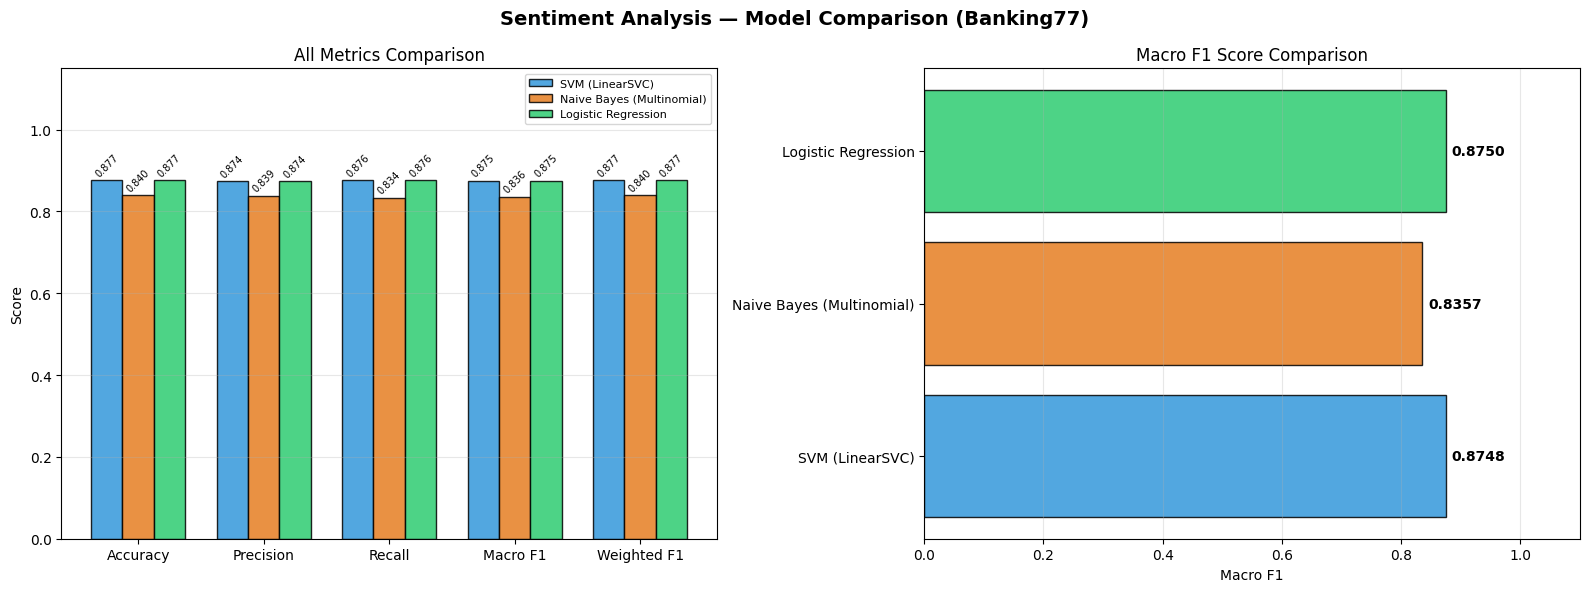

Comparison chart saved.


In [ ]:

metrics   = ['Accuracy', 'Precision', 'Recall', 'Macro F1', 'Weighted F1']
model_names = [r['model'] for r in results_list]
bar_colors  = ['#3498db', '#e67e22', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sentiment Analysis — Model Comparison (Banking77)', fontsize=14, fontweight='bold')

x       = np.arange(len(metrics))
width   = 0.25
for i, (res, color) in enumerate(zip(results_list, bar_colors)):
    vals = [
        res['accuracy'],
        res['precision'],
        res['recall'],
        res['macro_f1'],
        res['weighted_f1']
    ]
    bars = axes[0].bar(x + i*width, vals, width, label=res['model'], color=color, alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Comparison')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# -- bar for Macro F1
f1_scores = [r['macro_f1'] for r in results_list]
bars = axes[1].barh(model_names, f1_scores, color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Macro F1 Score Comparison')
axes[1].set_xlabel('Macro F1')
for bar, val in zip(bars, f1_scores):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved.')

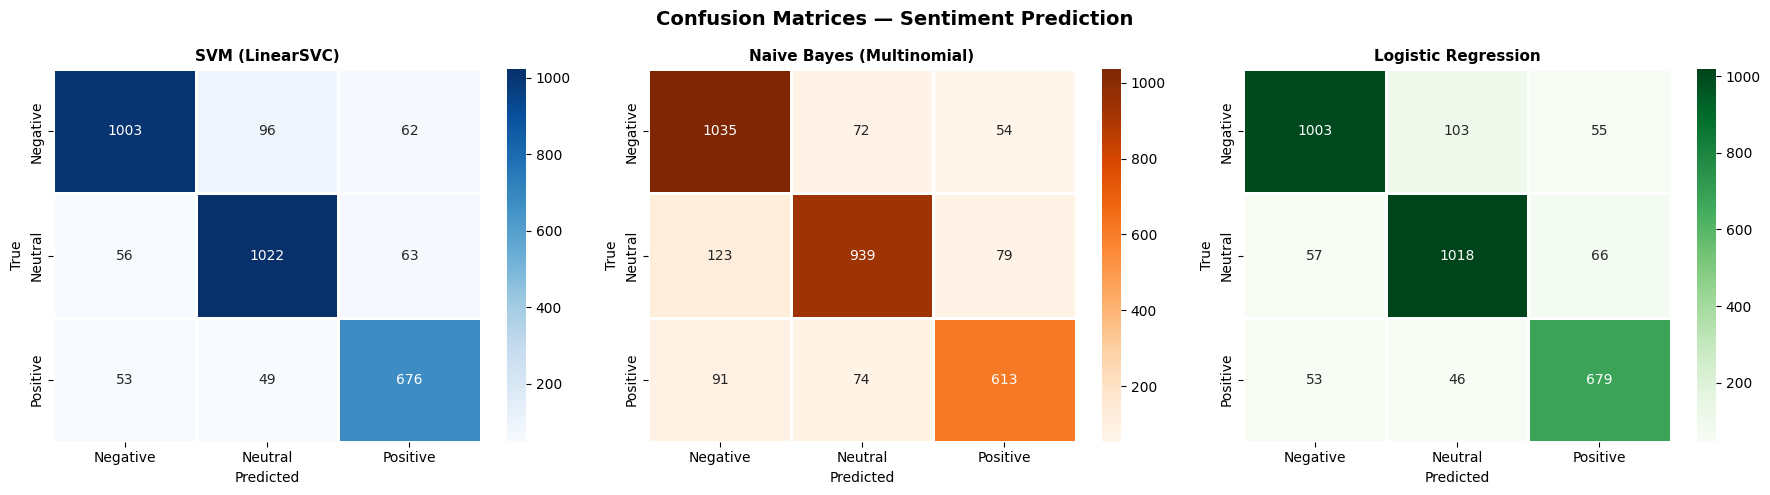

Confusion matrices saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Sentiment Prediction', fontsize=14, fontweight='bold')

cmaps = ['Blues', 'Oranges', 'Greens']
for ax, res, cmap in zip(axes, results_list, cmaps):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=classes, yticklabels=classes,
        linewidths=1, ax=ax
    )
    ax.set_title(res['model'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

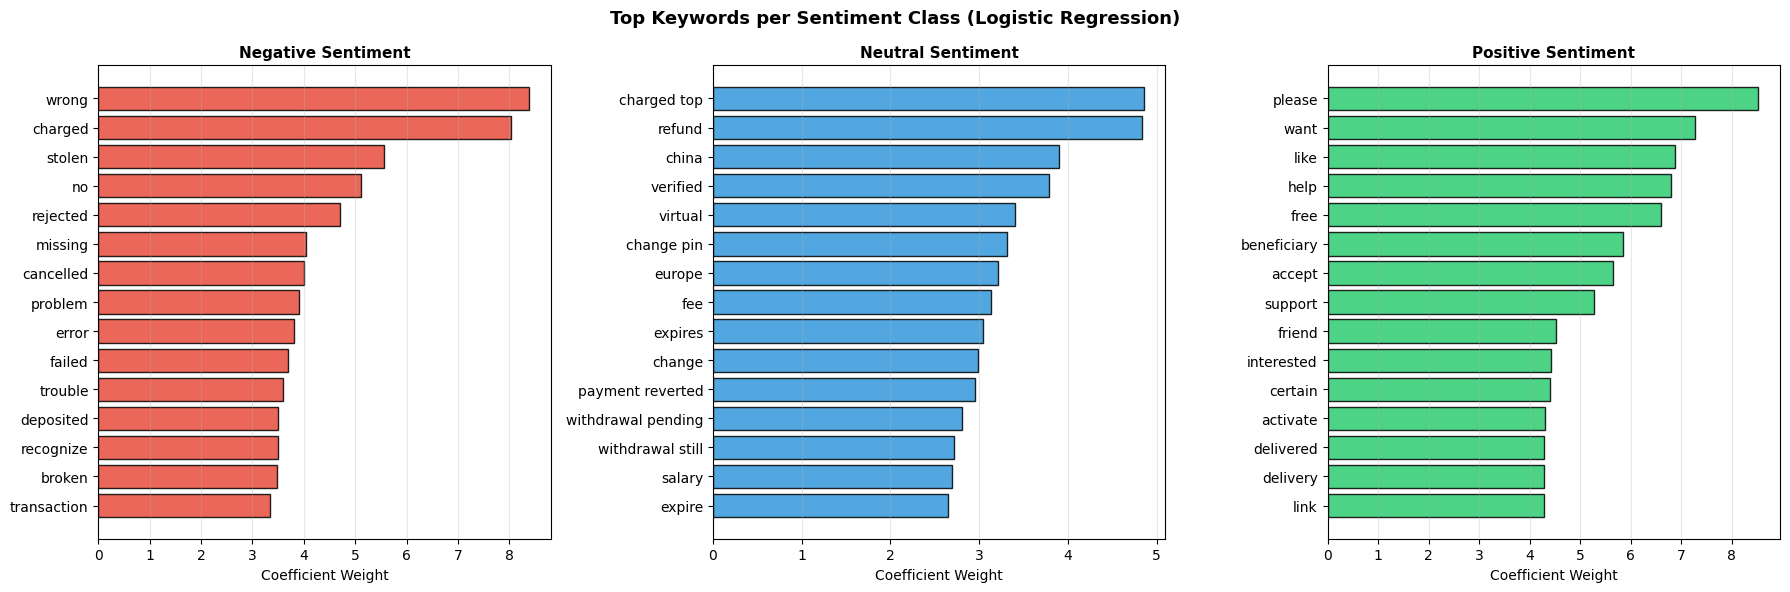

Top keywords plot saved.


In [ ]:

feature_names = tfidf.get_feature_names_out()
TOP_N = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top Keywords per Sentiment Class (Logistic Regression)', fontsize=13, fontweight='bold')

colors_map = {'Negative': '#e74c3c', 'Neutral': '#3498db', 'Positive': '#2ecc71'}

for i, (cls, color) in enumerate(colors_map.items()):
    cls_idx   = list(classes).index(cls)
    coefs     = lr_model.coef_[cls_idx]
    top_idx   = coefs.argsort()[-TOP_N:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = [coefs[j] for j in top_idx]

    axes[i].barh(top_words[::-1], top_vals[::-1], color=color, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{cls} Sentiment', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Coefficient Weight')
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top keywords plot saved.')

In [ ]:
def predict_sentiment(text: str):
    """Predict sentiment using all 3 models."""
    clean   = preprocess_text(text)
    vec     = tfidf.transform([clean])

    svm_pred = le.inverse_transform(svm_model.predict(vec))[0]
    nb_pred  = le.inverse_transform(nb_model.predict(vec))[0]
    lr_pred  = le.inverse_transform(lr_model.predict(vec))[0]

    # Logistic Regression also gives probability
    lr_proba = lr_model.predict_proba(vec)[0]
    proba_dict = {cls: f'{p*100:.1f}%' for cls, p in zip(le.classes_, lr_proba)}

    print(f'\n   Email    : {text}')
    print(f'   SVM      : {svm_pred}')
    print(f'   NaiveBayes: {nb_pred}')
    print(f'   LogReg   : {lr_pred}  {proba_dict}')


test_emails = [
    'My card has not arrived yet, it has been 2 weeks!',
    'I see a charge on my account that I did not make.',
    'What is my current balance?',
    'I sent money to my friend but they never received it.',
    'I lost my card while travelling abroad.',
    'Why was I charged an extra fee for my transfer?',
    'My PIN is not working at the ATM.',
    'Someone is using my card without my permission!',
    'How do I activate my new card?',
    'I successfully topped up my account, thank you!'
]

print('\n SENTIMENT PREDICTION DEMO')
print('=' * 65)
for email in test_emails:
    predict_sentiment(email)
print('\n' + '=' * 65)


 SENTIMENT PREDICTION DEMO

   Email    : My card has not arrived yet, it has been 2 weeks!
   SVM      : Negative
   NaiveBayes: Negative
   LogReg   : Negative  {'Negative': '66.7%', 'Neutral': '4.4%', 'Positive': '28.9%'}

   Email    : I see a charge on my account that I did not make.
   SVM      : Negative
   NaiveBayes: Negative
   LogReg   : Negative  {'Negative': '72.2%', 'Neutral': '26.4%', 'Positive': '1.4%'}

   Email    : What is my current balance?
   SVM      : Negative
   NaiveBayes: Negative
   LogReg   : Negative  {'Negative': '85.3%', 'Neutral': '11.0%', 'Positive': '3.7%'}

   Email    : I sent money to my friend but they never received it.
   SVM      : Negative
   NaiveBayes: Negative
   LogReg   : Positive  {'Negative': '46.4%', 'Neutral': '0.5%', 'Positive': '53.1%'}

   Email    : I lost my card while travelling abroad.
   SVM      : Negative
   NaiveBayes: Negative
   LogReg   : Negative  {'Negative': '88.7%', 'Neutral': '5.8%', 'Positive': '5.5%'}

   Email  

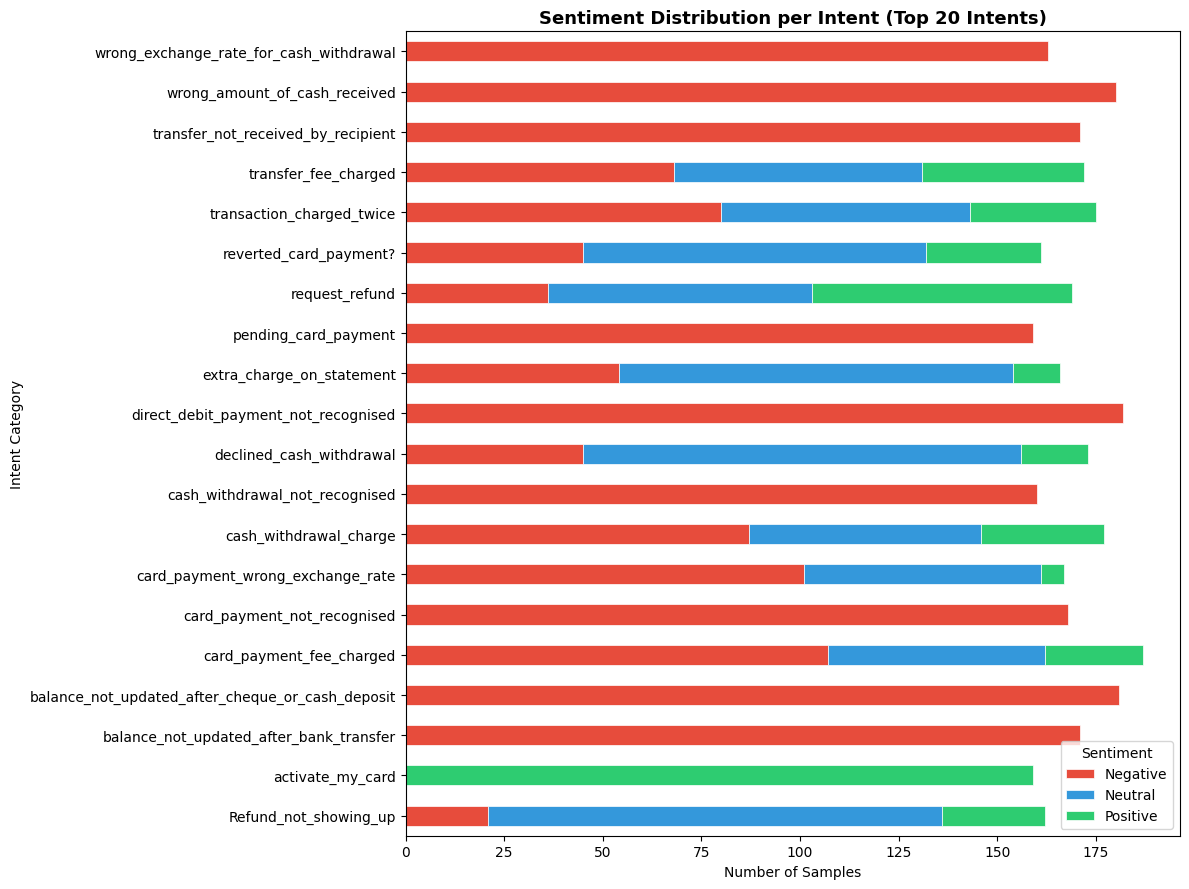

Sentiment per intent plot saved.


In [ ]:

top20_intents = train_df['category'].value_counts().head(20).index.tolist()
subset = train_df[train_df['category'].isin(top20_intents)]

pivot = subset.groupby(['category', 'sentiment']).size().unstack(fill_value=0)

for col in ['Negative', 'Neutral', 'Positive']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['Negative', 'Neutral', 'Positive']]

pivot.plot(
    kind='barh', stacked=True, figsize=(12, 9),
    color=['#e74c3c', '#3498db', '#2ecc71'],
    edgecolor='white', linewidth=0.5
)
plt.title('Sentiment Distribution per Intent (Top 20 Intents)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Samples')
plt.ylabel('Intent Category')
plt.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.savefig('sentiment_per_intent.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sentiment per intent plot saved.')

## ✅ Cell 15 — Final Summary

In [ ]:
best_model = compare_df.loc[compare_df['Macro F1'].idxmax()]

print()
print('=' * 60)
print('     SENTIMENT ANALYSIS — FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Dataset        : Banking77 (PolyAI — GitHub CSV)')
print(f'  Task           : 3-class Sentiment (Pos / Neu / Neg)')
print(f'  Features       : TF-IDF (15k vocab, unigrams+bigrams)')
print(f'  Train samples  : {len(train_df)}')
print(f'  Test  samples  : {len(test_df)}')
print(f'  Intent classes : {NUM_LABELS}')
print('-' * 60)
print(f'  Sentiment distribution (train):')
for sent, cnt in train_df["sentiment"].value_counts().items():
    print(f'    {sent:<12}: {cnt} samples ({cnt/len(train_df)*100:.1f}%)')
print('-' * 60)
print(compare_df.to_string(index=False))
print('-' * 60)
print(f'   Best Model  : {best_model["Model"]}')
print(f'     Accuracy    : {best_model["Accuracy"]}%')
print(f'     Macro F1    : {best_model["Macro F1"]}')
print('=' * 60)
print()
print('  Techniques used:')
print('     Same CSV dataset loading as DistilBERT notebook')
print('     VADER + domain-aware intent-based sentiment labelling')
print('     PII masking + lemmatization + negation-aware stopwords')
print('     TF-IDF (unigram + bigram, 15k features)')
print('    SVM (LinearSVC) with class_weight=balanced')
print('     Naive Bayes (Multinomial) with Laplace smoothing')
print('     Logistic Regression (multinomial, lbfgs)')
print('     Per-class keyword analysis (LR coefficients)')
print('     Confusion matrix + metric comparison charts')
print('=' * 60)


     SENTIMENT ANALYSIS — FINAL RESULTS SUMMARY
  Dataset        : Banking77 (PolyAI — GitHub CSV)
  Task           : 3-class Sentiment (Pos / Neu / Neg)
  Features       : TF-IDF (15k vocab, unigrams+bigrams)
  Train samples  : 10003
  Test  samples  : 3080
  Intent classes : 77
------------------------------------------------------------
  Sentiment distribution (train):
    Negative    : 4149 samples (41.5%)
    Neutral     : 3419 samples (34.2%)
    Positive    : 2435 samples (24.3%)
------------------------------------------------------------
                    Model  Accuracy  Precision  Recall  Macro F1  Weighted F1
          SVM (LinearSVC)     87.69     0.8739  0.8762    0.8748       0.8770
Naive Bayes (Multinomial)     83.99     0.8386  0.8341    0.8357       0.8395
      Logistic Regression     87.66     0.8741  0.8763    0.8750       0.8767
------------------------------------------------------------
   Best Model  : Logistic Regression
     Accuracy    : 87.66%
     Macr